### Inference Script

In [1]:
checkpoint_path = "./checkpoint/best_mobilenet_v2.pth"
img_path = "./classification_data/test/focused/1_17.png"
class_indices_path = "./checkpoint/class_indices.txt"

'focused'

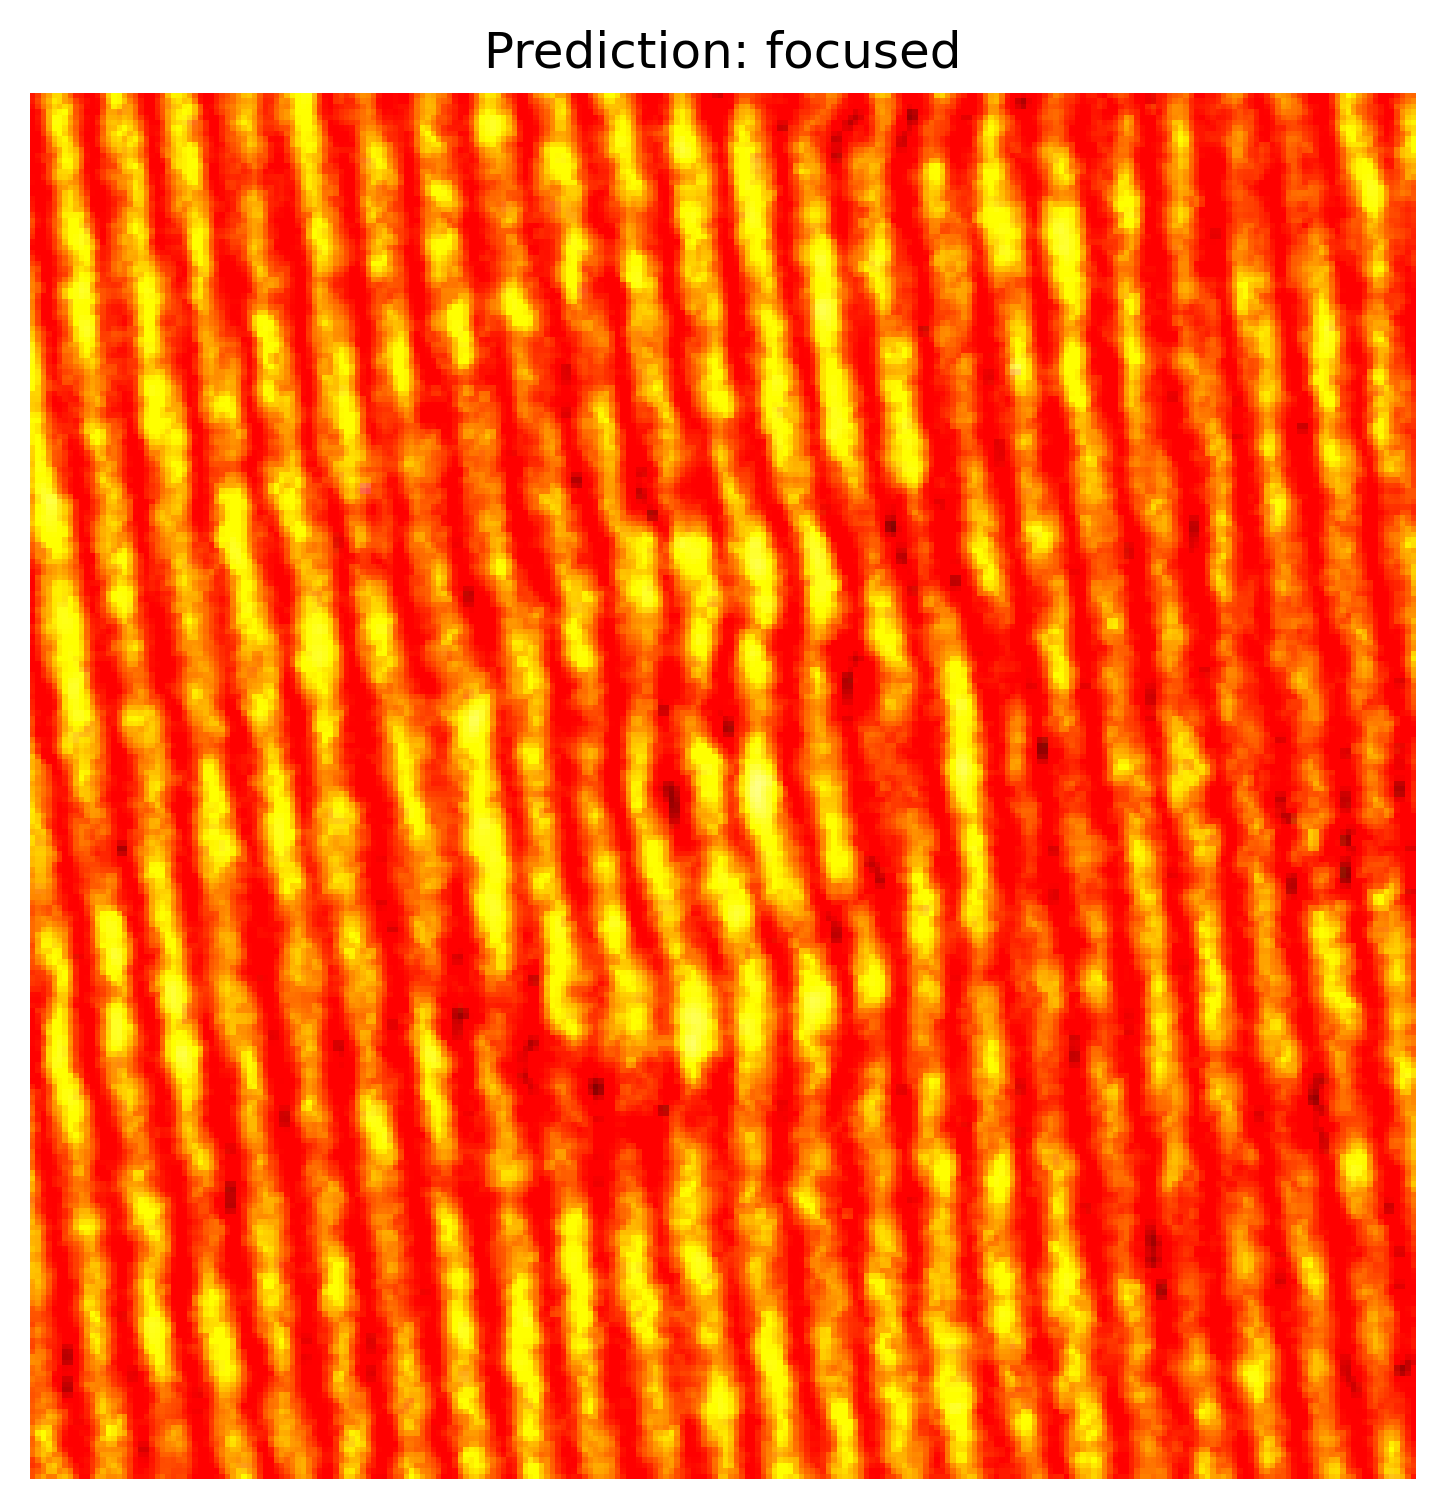

In [2]:
import json
import torch
from torch import nn
import torchvision
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

DEVICE = torch.device("mps") if torch.mps.is_available() else torch.device("cpu")

# Load model
model = torchvision.models.mobilenet_v2(weights=None)
num_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 2)
)
checkpoint = torch.load(checkpoint_path, map_location=torch.device("cpu"))

with open(class_indices_path, 'r') as f:
    class_to_idx = json.load(f)

idx_to_class = {v:k for k,v in class_to_idx.items()}


model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(DEVICE)
model.eval()

# Transform
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

def predict(image_path, plot=True):
    img = Image.open(image_path)
    image = transform(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        pred = model(image)
        pred_class = torch.argmax(torch.softmax(pred, dim=1), dim=1)
        prediction = idx_to_class[pred_class.item()]
    if plot:
        plt.figure(figsize=(6,6), dpi=300)
        plt.imshow(img)
        plt.title(f"Prediction: {prediction}")
        plt.axis("off")
    return prediction

predict(image_path=img_path)
